In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# 1. DATA PREPARATION
data_dir = "images_original"

filepaths = []
labels = []

# Read all images
for genre in os.listdir(data_dir):
    genre_path = os.path.join(data_dir, genre)
    
    if os.path.isdir(genre_path):
        for img in os.listdir(genre_path):
            filepaths.append(os.path.join(genre_path, img))
            labels.append(genre)

df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

# 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)

# 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

# MobileNetV2 expects pixels between -1 and 1, NOT 0 and 1.
# We replace rescale=1./255 with its specific preprocess_input function.
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Train data
train_data = datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

# Validation data
val_data = datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

# Test data
test_data = datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 699 validated image filenames belonging to 10 classes.
Found 150 validated image filenames belonging to 10 classes.
Found 150 validated image filenames belonging to 10 classes.


In [2]:

# Load the pre-trained MobileNetV2 model without the final classification layers
base_model = MobileNetV2(
    input_shape=(128, 128, 3), 
    include_top=False, 
    weights='imagenet' 
)

base_model.trainable = False


cnn = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(10, activation='softmax')
])

# Compile Model
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,618 (8.93 MB)

 Trainable params: 82,634 (322.79 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [3]:

early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=10, 
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_mobilenet_cnn.keras', 
    monitor='val_accuracy', 
    save_best_only=True
)

history = cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=50, 
    callbacks=[early_stop, checkpoint]
)


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 501ms/step - accuracy: 0.1660 - loss: 2.4428 - val_accuracy: 0.3067 - val_loss: 1.9209
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.2890 - loss: 1.9602 - val_accuracy: 0.4467 - val_loss: 1.6683
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.3305 - loss: 1.8657 - val_accuracy: 0.4800 - val_loss: 1.5447
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.3677 - loss: 1.7589 - val_accuracy: 0.5667 - val_loss: 1.4781
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.3863 - loss: 1.6857 - val_accuracy: 0.4933 - val_loss: 1.4501
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.4077 - loss: 1.6356 - val_accuracy: 0.5467 - val_loss: 1.3981
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.4464 - loss: 1.5684 - val_accuracy: 0.5467 - val_loss: 1.3685
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.4464 - loss: 1.5118 - val_accuracy: 0

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - accuracy: 0.5267 - loss: 1.4076

Final Test Accuracy: 0.5267


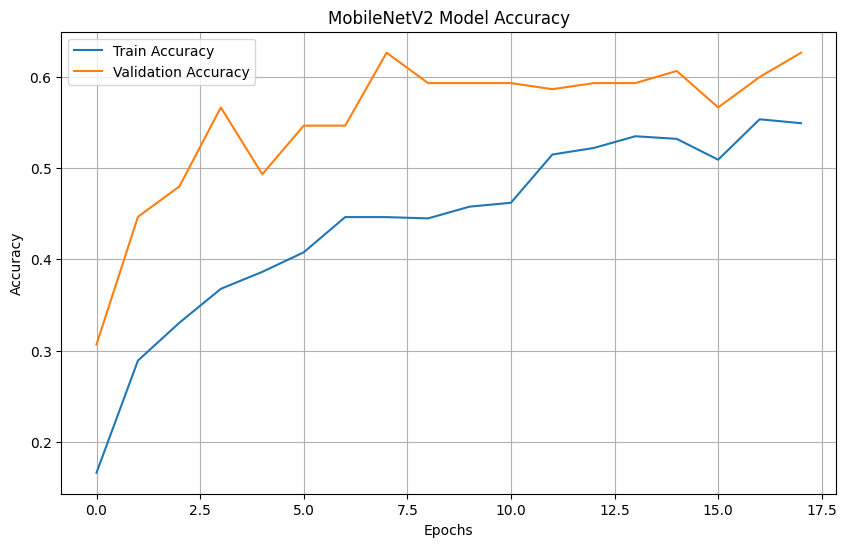

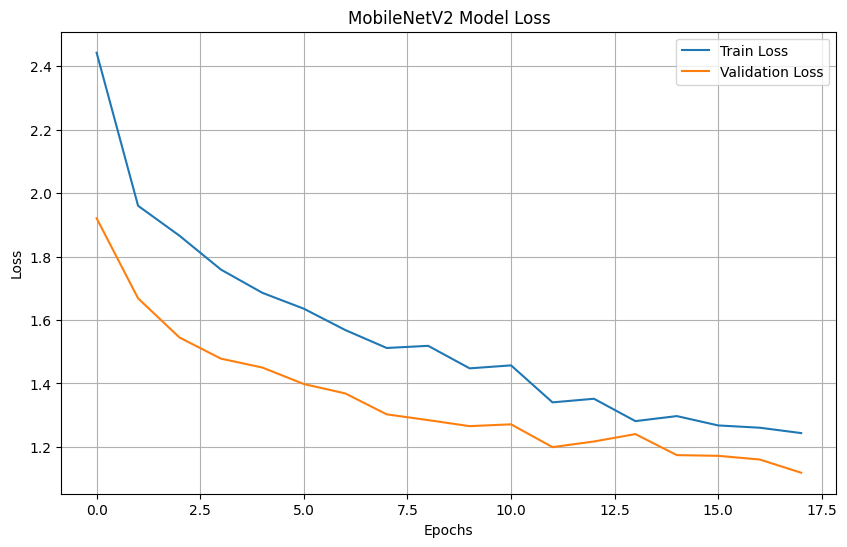

In [4]:

test_loss, test_acc = cnn.evaluate(test_data)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# Accuracy Graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
